In [386]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.ticker as mtick
import matplotlib.lines as mlines

In [ ]:
results = pd.read_csv('../../results/results_df.csv').drop(columns=['Unnamed: 0'])

df = results
df['fixed_cost'] = 250
df['total_cost'] = df['fixed_cost'] + df['total_route_cost']

grouped = df.groupby(['n_clusters', 'instance', 'day']).aggregate({'fixed_cost': 'sum', 'num_routes': 'sum', 'total_route_cost': 'sum', 'total_cost': 'sum', 'avg_route_duration': 'mean', 'max_route_cost': 'max', 'avg_freight': 'mean', 'clients': 'sum', 'max_freight': 'max', 'min_freight': 'min'}).reset_index()
final = grouped.reset_index().groupby('n_clusters').mean().reset_index()

df.to_csv('../../results/results_raw.csv')
grouped.to_csv('../../results/results_by_instance.csv')
final.to_csv('../../results/results_grouped.csv')

In [ ]:
grouped.sort_values(by='n_clusters')
df = grouped.sort_values(by='total_cost')[1:]
df = df.sort_values(by = 'instance')

freight_ref = df[['n_clusters', 'avg_freight']][df['clients']==1543].sort_values('n_clusters').reset_index()
vehicles_ref = df[['n_clusters', 'num_routes']][df['clients']==1543].sort_values('n_clusters').reset_index()
df = df.reset_index().drop(columns='index')

df['freight_ref'] = ''
df['vehicles_ref'] = ''
df['freight_diff'] = ''
df['vehicles_diff'] = ''
df['clients_diff'] = ''
df['fulfillment_rate'] = ''
for i, row in df.iterrows():
    df['freight_ref'][i] = freight_ref['avg_freight'][freight_ref['n_clusters']==row['n_clusters']].iloc[0]
    df['vehicles_ref'][i] = vehicles_ref['num_routes'][freight_ref['n_clusters']==row['n_clusters']].iloc[0]
    df['freight_diff'][i] = df['freight_ref'][i] - df['avg_freight'][i]
    df['vehicles_diff'][i] = df['vehicles_ref'][i] - df['num_routes'][i]
    df['clients_diff'][i] = df['clients'][i]/df['num_routes'][i]*df['vehicles_diff'][i]
    if df['clients_diff'][i] < 0:
        df['fulfillment_rate'][i] = 1-df['clients_diff'][i]*(-1)/df['clients'][i]
    else:
        df['fulfillment_rate'][i] = 1
# df

### Scatter

In [ ]:
# Extract the required columns
x = df['instance']
y = df['num_routes']
nums = df['n_clusters']

# Create colormap with skipping white color
cmap = cm.get_cmap('bone')
cmap = colors.ListedColormap([cmap(i) for i in range(0, cmap.N-100)])
norm = colors.Normalize(vmin=nums.min(), vmax=nums.max())

# Create scatter plot with consistent color pattern
scatter = plt.scatter(x, y, c=nums, cmap=cmap, norm=norm)


# Calculate mean values for each 'n_clusters' category
mean_values = df.groupby('n_clusters')['num_routes'].mean()

# Add mean lines
for num, mean_value in mean_values.items():
    plt.axhline(mean_value, color=cmap(norm(num)), linestyle='--', label=f'Mean ({mean_value})')
    plt.text(+5.3, mean_value, f'{mean_value:.2f}', color=cmap(norm(num)), ha='left', va='center')

# Add axis labels and a title
plt.xlabel('Instance')
plt.ylabel('Number of vehicles')
plt.title('Number of vehicles per scenario and instance over 30 days')

# Create legend
legend_elements = []
for num in np.sort(nums.unique())[::-1]:
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(norm(num)), markersize=8, label=f'scenario = {num}'))
legend_elements.append(plt.Line2D([0], [0], color='gray', linestyle='--', label='Mean'))
plt.legend(handles=legend_elements)

# Display the plot
plt.show()

### Boxplot

In [ ]:
# Create a dictionary to store the data for each 'n_clusters' category
data = {}
for num in np.sort(df['n_clusters'].unique())[::-1]:
    data[num] = df[df['n_clusters'] == num]['freight_diff'].values

# Create a list to store the boxplot labels
labels = [f'{num}' for num in data.keys()]

# Create the boxplot
fig, axes = plt.subplots()
medianprops = dict(linestyle='-', linewidth=1.5, color='orange')
bplot = axes.boxplot(data.values(), labels=labels, vert=False, showmeans=True, medianprops=medianprops)

# Add legend
legend_elements = []
legend_elements.append(plt.Line2D([0], [0], color='orange', linestyle='-', label='Median'))
legend_elements.append(mlines.Line2D([], [], color='green', marker='^', linestyle='None',
                          markersize=6, label='Mean'))
plt.legend(handles=legend_elements)

# Fill with colors
values = list(data.keys())
cmap = cm.get_cmap('bone')
cmap = colors.ListedColormap([cmap(i) for i in range(0, cmap.N-100)])
rescale = lambda values: (values - np.min(values)) / (np.max(values) - np.min(values))
for patch, color in zip(bplot['boxes'], cmap(rescale(values))):
    patch.set(color=color, fillstyle='full')

plt.axvline(0, color='gray', linestyle='--')

# Add axis labels and a title
plt.xlabel('Freight difference')
plt.ylabel('Scenario')
plt.title('Freight difference by scenario')

# Add labels for mean values
means = bplot['means']
for mean in means:
    mean_xvalue = mean.get_xdata()[0]
    mean_yvalue = mean.get_ydata()[0]
    axes.annotate(f'R$ {mean_xvalue:.2f}', xy=(mean_xvalue, mean_yvalue), xytext=(0, 22),
                  textcoords='offset points', ha='center', va='center', color='green',backgroundcolor='w', fontsize=8, weight='bold')

# Add labels for median values
medians = bplot['medians']
for median in medians:
    median_xvalue = median.get_xdata()[0]
    median_yvalue = median.get_ydata()[0]
    axes.annotate(f'R$ {median_xvalue:.2f}', xy=(median_xvalue, median_yvalue), xytext=(0, -10),
                  textcoords='offset points', ha='center', va='center', color='orange',backgroundcolor='w', fontsize=8, weight='bold')
# Display the plot
plt.show()


### Bar chart

In [ ]:
clients_a = df[df['clients_diff']<0][['n_clusters','instance','clients_diff']].groupby(by=['n_clusters', 'instance']).sum().reset_index()
clients_a = clients_a[['n_clusters', 'clients_diff']].groupby(by='n_clusters').mean().reset_index()
clients_a['served'] = ''
clients_a['pct_served'] = ''

total_clients = df[['n_clusters','instance','clients']].groupby(by=['n_clusters', 'instance']).sum().reset_index()
total_clients = total_clients[['n_clusters', 'clients']].groupby(by='n_clusters').mean().reset_index()
total_clients['clients'][2] = 44871.5

for i, row in clients_a.iterrows():
    clients_a['served'][i] = total_clients['clients'][i] + clients_a['clients_diff'][i]
    clients_a['pct_served'][i] = (total_clients['clients'][i] + clients_a['clients_diff'][i])/total_clients['clients'][i]*100

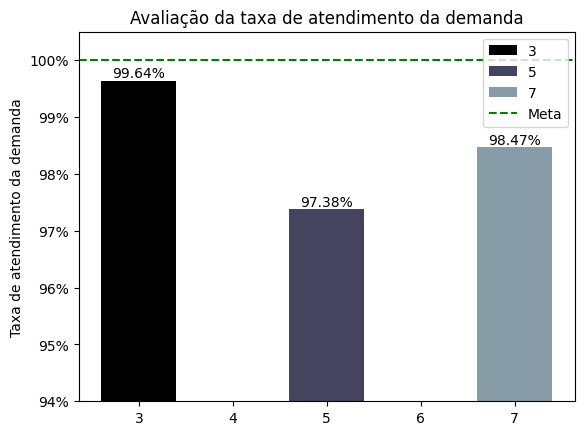

In [401]:
fig, ax = plt.subplots()

clients_served = clients_a['pct_served']
scenarios = clients_a['n_clusters']
bar_labels = clients_a['n_clusters']

width = 0.25  # the width of the bars
multiplier = 0

# Fill with colors
values = bar_labels
cmap = cm.get_cmap('bone')
cmap = colors.ListedColormap([cmap(i) for i in range(0, cmap.N-100)])
rescale = lambda values: (values - np.min(values)) / (np.max(values) - np.min(values))

bar = ax.bar(scenarios,clients_served, label=bar_labels, color=cmap(rescale(values)))

# Add percentage-formatted bar labels
ax.bar_label(bar, labels=[f'{val:.2f}%' for val in clients_served])

plt.axhline(100, color='green', linestyle='--', label=f'Target')

# Formata o eixo y em porcentagem
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
   
ax.set_ylim([94, 100.5])
ax.set_ylabel('Demand fulfillment rate')
ax.set_title('Demand fulfillment rate')
plt.legend()

plt.show()